# Loss Function Geometry - Real-Time Tracking Notebook
This notebook tracks the impact of different loss functions (KL, MSE, Cosine Similarity) on subliminal learning transfer.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the 95% confidence interval for standard error mapping
def ci_95(arr):
    if len(arr) < 2:
        return 0.0
    return 1.96 * np.std(arr) / np.sqrt(len(arr))

# Load the cached experimental results
cache_file = '../experiments/cache/loss_function_geometry.json'
if os.path.exists(cache_file):
    with open(cache_file, 'r') as f:
        data = json.load(f)
else:
    print('Cache file not found yet.')
    data = {}

In [2]:
if data:
    records = []
    for key, val in data.items():
        if key in ['Reference', 'Teacher']:
            continue
        loss_type = key
        for metric, arr in val.items():
            mean_val = np.mean(arr)
            err_val = ci_95(arr)
            records.append({'Loss Function': loss_type, 'Metric': metric, 'Mean': mean_val, 'Error': err_val})

    df = pd.DataFrame(records)
    display(df)

,Loss Function,Metric,Mean,Error
0,KL,Student (aux. only),0.51648,0.079349
1,KL,Student (all logits),0.90738,0.005934
2,KL,Cross-model (aux. only),0.20488,0.128377
3,KL,Cross-model (all logits),0.74786,0.060753
4,MSE,Student (aux. only),0.65439,0.050421
5,MSE,Student (all logits),0.91339,0.004813
6,MSE,Cross-model (aux. only),0.16062,0.107704
7,MSE,Cross-model (all logits),0.73074,0.049646
8,Cosine,Student (aux. only),0.50378,0.080767
9,Cosine,Student (all logits),0.90236,0.007550


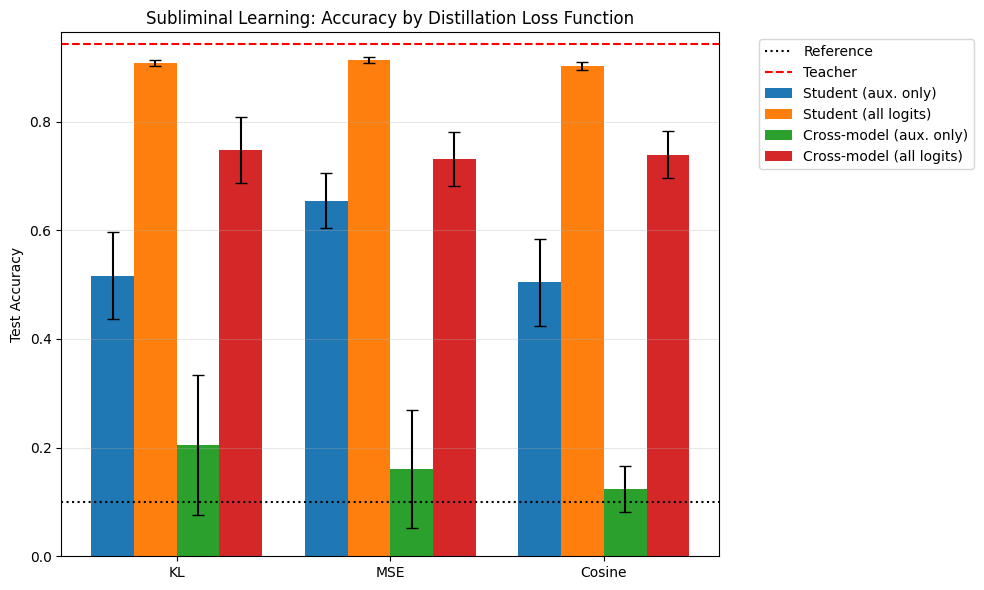

In [3]:
if data and 'df' in locals() and not df.empty:
    # Generate grouping bar charts to visualize varying metrics across loss functions
    metrics = df['Metric'].unique()
    loss_funcs = df['Loss Function'].unique()
    
    x = np.arange(len(loss_funcs))  # the label locations
    width = 0.20  # the width of the bars
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i, metric in enumerate(metrics):
        subset = df[df['Metric'] == metric].set_index('Loss Function')
        # Align data carefully enforcing the strict order of X-axis loss grouping
        means = [subset.loc[lf, 'Mean'] if lf in subset.index else 0 for lf in loss_funcs]
        errs = [subset.loc[lf, 'Error'] if lf in subset.index else 0 for lf in loss_funcs]
        
        offset = width * i
        ax.bar(x + offset, means, width, yerr=errs, label=metric, capsize=4)
    
    # Add the horizontal reference tracking lines for Baseline and Teacher averages
    if 'Reference' in data:
        ax.axhline(np.mean(data['Reference']), ls=':', c='black', label='Reference')
    if 'Teacher' in data:
        ax.axhline(np.mean(data['Teacher']), ls='--', c='red', label='Teacher')
        
    ax.set_ylabel('Test Accuracy')
    ax.set_title('Subliminal Learning: Accuracy by Distillation Loss Function')
    ax.set_xticks(x + width * (len(metrics) - 1) / 2)
    ax.set_xticklabels(loss_funcs)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()